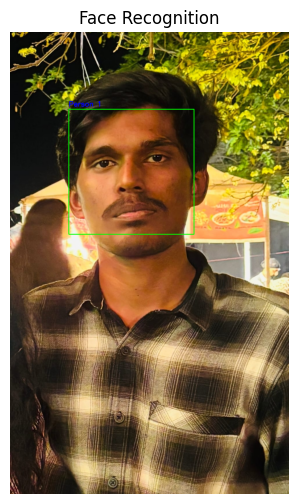

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Create LBPH Face Recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()

faces = []
labels = []

# Training images
train_images = ["person1.jpg", "person2.jpeg"]

for i, image_name in enumerate(train_images):

    img = cv2.imread(image_name)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    detected_faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in detected_faces:

        faces.append(gray[y:y+h, x:x+w])

        labels.append(i)

# Train recognizer
recognizer.train(faces, np.array(labels))

# Test image
test = cv2.imread("face.jpeg")

gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

detected_faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in detected_faces:

    face = gray[y:y+h, x:x+w]

    label, confidence = recognizer.predict(face)

    cv2.rectangle(test, (x, y), (x+w, y+h), (0,255,0), 2)

    cv2.putText(
        test,
        "Person " + str(label + 1),
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,0,0),
        2
    )

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(test, cv2.COLOR_BGR2RGB))
plt.title("Face Recognition")
plt.axis("off")
plt.show()